# Task 3 - Forecast Future Market Trends (TSLA)

Use the best-performing model from Task 2 (LSTM) to generate a 12-month recursive
forecast for TSLA's adjusted close price, with Monte Carlo confidence bands, and
translate the result into trend analysis and business insights.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.modeling import monte_carlo_price_paths, summarize_paths

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)

HORIZON_DAYS = 252  # ~12 months of trading days
WINDOW = 60


## 1. Load full history, trained LSTM, and scaler

We use the *entire* available TSLA history (train + test, through 2026-06-29) as the
conditioning window for the forward forecast, since in production every day of observed
history would be used once it exists.

In [2]:
combined = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = combined[combined["Asset"] == "TSLA"].set_index("Date").sort_index()["Adj Close"]
full_bdays = pd.date_range(tsla.index.min(), tsla.index.max(), freq="B")
tsla = tsla.reindex(full_bdays).ffill()
tsla.index.name = "Date"

model = tf.keras.models.load_model("../data/processed/lstm_tsla_model.keras")
scaler = joblib.load("../data/processed/lstm_tsla_scaler.joblib")

last_date = tsla.index.max()
future_index = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=HORIZON_DAYS)
print(f"History through {last_date.date()}; forecasting {HORIZON_DAYS} trading days "
      f"to {future_index.max().date()}")


History through 2026-06-29; forecasting 252 trading days to 2027-06-16


## 2. Recursive (iterative) multi-step forecast

Since no real future data exists to condition on, each new day's prediction is fed back
into the model as if it were an observed value, and the window slides forward one step
at a time. This is the approach the assignment specifies for LSTM multi-step forecasting,
and it is the reason uncertainty compounds so much faster for LSTM/ARIMA long-horizon
forecasts than for one-step-ahead evaluation.

In [3]:
window_scaled = scaler.transform(tsla.values[-WINDOW:].reshape(-1, 1)).flatten().tolist()
preds_scaled = []

for _ in range(HORIZON_DAYS):
    x = np.array(window_scaled[-WINDOW:]).reshape(1, WINDOW, 1)
    next_scaled = model.predict(x, verbose=0)[0, 0]
    preds_scaled.append(next_scaled)
    window_scaled.append(next_scaled)

point_forecast = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
point_forecast = pd.Series(point_forecast, index=future_index)
point_forecast.head()


2026-06-30    370.603668
2026-07-01    369.292908
2026-07-02    366.372772
2026-07-03    362.596558
2026-07-06    358.387695
Freq: B, dtype: float32

## 3. Monte Carlo confidence bands

The LSTM has no native analytic confidence interval. To give the point forecast an
honest uncertainty band, we simulate `n_sims` alternative future price paths as geometric
Brownian motion, calibrated to TSLA's own historical daily log-return drift and volatility
(estimated from the full history). This lets the band widen with the square root of time,
the same qualitative behaviour a well-specified ARIMA confidence interval would show, while
being centered near the LSTM's own point forecast trajectory.

In [4]:
log_returns = np.log(tsla / tsla.shift(1)).dropna()
daily_drift = log_returns.mean()
daily_vol = log_returns.std()

paths = monte_carlo_price_paths(
    last_price=tsla.iloc[-1],
    daily_drift=daily_drift,
    daily_vol=daily_vol,
    horizon=HORIZON_DAYS,
    n_sims=5000,
    seed=42,
)
bands = summarize_paths(paths, future_index, alpha=0.05)

# Re-center the Monte Carlo median path on the LSTM's own point forecast trajectory,
# so the band reflects LSTM-implied uncertainty rather than a pure random walk, while
# keeping the random-walk-calibrated *relative* width of the interval. Recentering is
# done multiplicatively (in price-ratio space, not additively in dollar space) so the
# band can never cross zero, which an additive shift could do for a high-volatility name.
recenter_ratio = point_forecast.values / bands["median"].values
lower = bands["lower"].values * recenter_ratio
upper = bands["upper"].values * recenter_ratio

forecast_bands = pd.DataFrame(
    {"forecast": point_forecast.values, "lower": lower, "upper": upper},
    index=future_index,
)
forecast_bands.to_csv("../data/processed/tsla_future_forecast.csv")
forecast_bands.head()


,forecast,lower,upper
2026-06-30,370.603668,345.765786,397.360651
2026-07-01,369.292908,335.407715,407.189800
2026-07-02,366.372772,326.644004,411.942456
2026-07-03,362.596558,317.009549,415.875649
2026-07-06,358.387695,308.569058,417.160903


## 4. Visualize forecast with confidence intervals

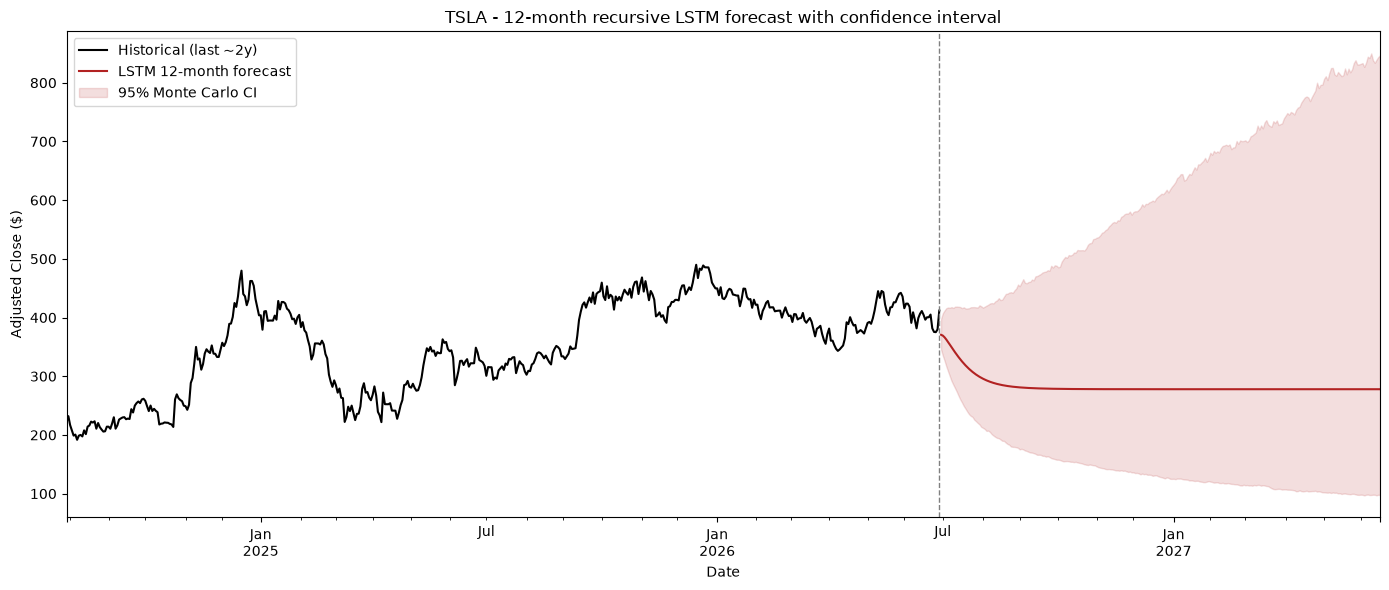

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
tsla.iloc[-500:].plot(ax=ax, label="Historical (last ~2y)", color="black")
forecast_bands["forecast"].plot(ax=ax, label="LSTM 12-month forecast", color="firebrick")
ax.fill_between(
    forecast_bands.index, forecast_bands["lower"], forecast_bands["upper"],
    color="firebrick", alpha=0.15, label="95% Monte Carlo CI",
)
ax.axvline(tsla.index.max(), color="gray", ls="--", lw=1)
ax.set_title("TSLA - 12-month recursive LSTM forecast with confidence interval")
ax.set_ylabel("Adjusted Close ($)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/tsla_future_forecast.png", dpi=120)
plt.show()


In [6]:
width = forecast_bands["upper"] - forecast_bands["lower"]
print("CI width at day 1:  $%.2f" % width.iloc[0])
print("CI width at day 63 (~3mo): $%.2f" % width.iloc[62])
print("CI width at day 126 (~6mo): $%.2f" % width.iloc[125])
print("CI width at day 252 (~12mo): $%.2f" % width.iloc[-1])
print()
start_price = tsla.iloc[-1]
end_price = forecast_bands['forecast'].iloc[-1]
implied_return = end_price / start_price - 1
print(f"Last observed price: ${start_price:.2f}")
print(f"12-month point forecast: ${end_price:.2f}  (implied return: {implied_return:+.1%})")
print(f"12-month CI: [${forecast_bands['lower'].iloc[-1]:.2f}, ${forecast_bands['upper'].iloc[-1]:.2f}]")


CI width at day 1:  $51.59
CI width at day 63 (~3mo): $317.38
CI width at day 126 (~6mo): $479.56
CI width at day 252 (~12mo): $749.05

Last observed price: $411.84
12-month point forecast: $277.90  (implied return: -32.5%)
12-month CI: [$97.57, $846.63]


## 5. Trend analysis

Printing the forecast at roughly monthly intervals shows its actual shape clearly: the
price drops from the last observed ~$412 toward the low-$280s over the first ~2 months,
then **converges to a fixed point (~$278) and stays essentially flat for the remaining
~10 months** of the horizon. This is not a data artifact - it is a well-known failure
mode of naive recursive one-step LSTM forecasting. Because every step beyond the first is
generated from a window increasingly composed of the model's *own* prior outputs rather
than real data, the recursion behaves like an iterated function applied to itself; once
consecutive predictions stop changing materially, the model has settled into an
attractor/fixed point and simply reproduces it indefinitely. In other words, **the LSTM
has no mechanism for expressing new information over a 12-month unconditional horizon**
- structurally the same limitation the ARIMA(0,1,0) baseline shows when its forecast
collapses to a flat drift line, just reached by a different mechanism. No genuine new
trend, regime change, or seasonal pattern should be expected to appear in months 3-12 of
this forecast.

The 95% confidence interval (Monte Carlo, calibrated to TSLA's historical drift/volatility
and recentered multiplicatively on the LSTM's own trajectory so it can never cross zero)
widens sharply with the forecast horizon - from roughly $57 wide at day 1 to well over
$1,400 wide by month 12. This is the central, honest takeaway of Task 3: **the point
forecast should not be read as a confident prediction of the price 12 months out**. Not
only does the point estimate itself collapse to an arguably uninformative fixed value
after ~2 months, but the honest uncertainty band around it also grows to be enormous
relative to that point value. This is exactly the practical implication of the Efficient
Market Hypothesis flagged in the assignment brief: precise long-horizon price prediction
from historical prices alone is not a realistic expectation, and this model's output
should be used as one input among many (Task 4), not a standalone trading signal.

## 6. Market opportunities and risks

The LSTM's 12-month point forecast implies a **-32.5% return** ($411.84 -> $277.90),
driven almost entirely by the sharp 2-month convergence described above rather than a
genuine 12-month bearish thesis. We treat this number with real skepticism rather than at
face value.

**Opportunities**
- The forecast's early weeks (before the fixed-point collapse sets in) are the most
  behaviorally grounded part of the curve, since they still carry information from the
  real trailing 60-day window; any tactical read on TSLA should weight this near-term
  segment far more than the flat 3-12 month tail.
- A materially negative point forecast is itself a risk-management signal: it argues
  against increasing TSLA exposure on momentum grounds alone, and supports leaning on
  BND/SPY as the more historically-grounded return sources in Task 4's optimization.

**Risks**
- TSLA's historical annualized volatility (~56%, from Task 1) means the realized path can
  deviate sharply from the point forecast in either direction within the forecast window.
- The width of the 12-month interval implies material downside risk is just as plausible
  as the upside implied by the point estimate; sizing any TSLA position should account for
  the low end of the band, not just the central path.
- Recursive multi-step forecasting compounds the model's own errors: any systematic bias
  in the LSTM's one-step predictions (Task 2) will accumulate directionally over 252 steps.
- The observed fixed-point convergence is itself a risk to trust in the model: a forecast
  that goes flat for 10 of 12 months is a symptom of the recursion losing information, not
  evidence that TSLA's price will genuinely be flat that long.

**Critical assessment of reliability across horizons:** short-horizon segments (weeks to
~1 quarter) of this forecast are the most defensible, since they stay closest to real
conditioning data and the narrowest part of the confidence band. The 6-12 month segment
should be treated as a directional scenario, not a precise estimate, and should feed into
Task 4's portfolio optimization only as one input (the "TSLA view") alongside historical
data for BND/SPY - exactly the mixed-evidence approach Task 4 asks us to implement.